**Temat: Budowa scenariusza opisowego badawczego dla Produkcji Przemysłowej w Niemczech (2024–2026)**

**Autorzy:** Piotr Wiśniewski, Izabela Reszka, Klaudia Woźniak

**Wstęp i kontekst badawczy**

Transformacja energetyczna, znana w Niemczech jako Energiewende, stanowi jeden z najbardziej złożonych procesów gospodarczych XXI wieku. Polega ona na fundamentalnej przebudowie sektora – odchodzeniu od paliw kopalnych i energetyki jądrowej na rzecz odnawialnych źródeł energii (OZE). Proces ten charakteryzuje się wysoką niepewnością i złożonością, co czyni go idealnym obiektem do zastosowania metod scenariuszowych.

W przeciwieństwie do tradycyjnego prognozowania (ekstrapolacji trendów), podejście scenariuszowe przyjęte w tym projekcie zakłada, że przyszłość nie jest jednolitym ciągiem zdarzeń, lecz zbiorem alternatywnych możliwości zależnych od kluczowych czynników otoczenia: cen, technologii oraz stabilności systemu.

**Cel projektu i przedmiot badań**

Głównym celem projektu jest budowa scenariusza opisowego badawczego, który pozwoli zidentyfikować przyszłe ścieżki kształtowania się popytu na energię w Niemczech.

*   Obiekt badań (Zmienna endogeniczna): Całkowite zużycie energii (energy_consumption). Jest to zmienna syntetyczna, traktowana jako "barometr" kondycji gospodarki i przemysłu.
*   Horyzont badawczy: Krótkookresowy/Średniookresowy (2024–2026).
*   Podejście: Analiza wpływu zmiennych egzogenicznych (otoczenia) na obiekt badań w celu zarysowania wariantów: optymistycznego, bazowego i pesymistycznego.

**Źródła i charakterystyka danych**

Podstawą empiryczną analizy są dane rzeczywiste o wysokiej granularności, przetworzone do szeregów miesięcznych.

*   Źródło pierwotne: ENTSO-E Transparency Platform (Europejska Sieć Operatorów Systemów Przesyłowych) – centralne repozytorium danych wymagane prawem UE (Rozporządzenie nr 543/2013).
*   Zakres czasowy: Styczeń 2015 – Listopad 2025 (ponad 10 lat obserwacji, 130+ punktów danych).
*   Obszar: Niemcy (DE), z uwzględnieniem historycznej unifikacji stref cenowych (DE-AT-LU / DE-LU).

**Proces przygotowania danych (ETL)**

Surowe dane o granularności 15-minutowej (generacja, obciążenie) oraz godzinowej (ceny) zostały poddane agregacji do poziomu miesięcznego (resample('ME')). Pozwoliło to na wyeliminowanie szumu dobowego i skupienie się na trendach makroekonomicznych oraz sezonowości rocznej.


**Zmienne diagnostyczne (Czynniki otoczenia)**

Do budowy scenariuszy wyselekcjonowano zestaw kluczowych zmiennych, które opisują siły napędowe rynku:

| Zmienna | Nazwa w modelu | Opis i znaczenie w scenariuszu |
| :--- | :--- | :--- |
| **Cena Rynkowa** | `market_price` | Średnia cena hurtowa (Day-Ahead) [EUR/MWh]. Kluczowy czynnik kosztowy dla przemysłu. Wysoka cena może prowadzić do destrukcji popytu. |
| **Udział OZE** | `res_share` | Odsetek energii z wiatru, słońca i biomasy w miksie. Miernik postępu transformacji technologicznej. |
| **Udział Paliw Kopalnych** | `fossil_share` | Odsetek energii z węgla i gazu. Zmienna determinująca emisyjność i koszty uprawnień CO2. |
| **Zmienność Cen** | `price_volatility` | Odchylenie standardowe cen w miesiącu. Mierzy ryzyko i niepewność rynkową. |
| **Stabilność Systemu** | `system_stability` | Błąd prognozy operatora (MAPE). Wskaźnik bezpieczeństwa energetycznego – im wyższy błąd, tym trudniejsze bilansowanie systemu opartego na OZE. |


**Uzasadnienie doboru metody**

Wykorzystanie danych z ENTSO-E gwarantuje wiarygodność i porównywalność międzynarodową. Zastosowanie podejścia scenariuszowego (zamiast prostej regresji) jest uzasadnione obecną niestabilnością geopolityczną i technologiczną rynku energii, gdzie proste przedłużanie trendów historycznych obarczone jest zbyt dużym błędem.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Konfiguracja wykresów dla czytelności w raporcie
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-whitegrid')

# === 1. PRZYGOTOWANIE DANYCH ===
# Wczytanie danych
df = pd.read_csv('dane_miesieczne_DE.csv')

# Tworzenie poprawnej osi czasu (Data) z kolumn 'year' i 'month'
# Dodajemy dzień=1, aby Pandas rozpoznał to jako datę
df['Date'] = pd.to_datetime(df[['year', 'month']].assign(DAY=1))
df.set_index('Date', inplace=True)

# Definicja zmiennych
target_var = 'energy_consumption'  # Nasz obiekt badań
# Zmienne otoczenia dostępne w Twoim pliku
exog_vars = ['market_price', 'res_share', 'fossil_share', 'price_volatility', 'system_stability']

# Identyfikacja zjawisk i Ilościowy opis powiązań

Celem tego kroku jest transformacja surowych danych w spójny szereg czasowy oraz weryfikacja statystyczna hipotez dotyczących wpływu otoczenia na obiekt badań. Nie opieramy się tu na intuicji, lecz na twardych wskaźnikach korelacji, co jest wymogiem metody Ilościowego opisu powiązań.

**Realizowane zadania:**

1.   **Inżynieria cech:**

*   Konstrukcja ciągłej osi czasu (Datetime Index) poprzez syntezę kolumn year i month. Jest to niezbędne do obsługi funkcji bibliotek statsmodels i pandas dedykowanych dla szeregów czasowych.
*   Ustawienie częstotliwości próbkowania na miesięczną (Month-End).

2.   **Analiza korelacji:**

*   Wyznaczenie macierzy korelacji dla zmiennych numerycznych.
*   Szukamy silnych związków liniowych między zmienną objaśnianą (energy_consumption) a zmiennymi objaśniającymi (otoczeniem).
*   Kluczowa hipoteza: Sprawdzamy, czy istnieje ujemna korelacja między ceną (market_price) a zużyciem (efekt elastyczności cenowej popytu) oraz jak udział OZE (res_share) wpływa na zmienność rynku.

Identyfikacja "sił napędowych"jest fundamentem budowy scenariuszy. Tylko zmienne wykazujące istotną statystycznie korelację ze zmienną endogeniczną mogą być podstawą do różnicowania wariantów przyszłości (scenariusza optymistycznego/pesymistycznego).

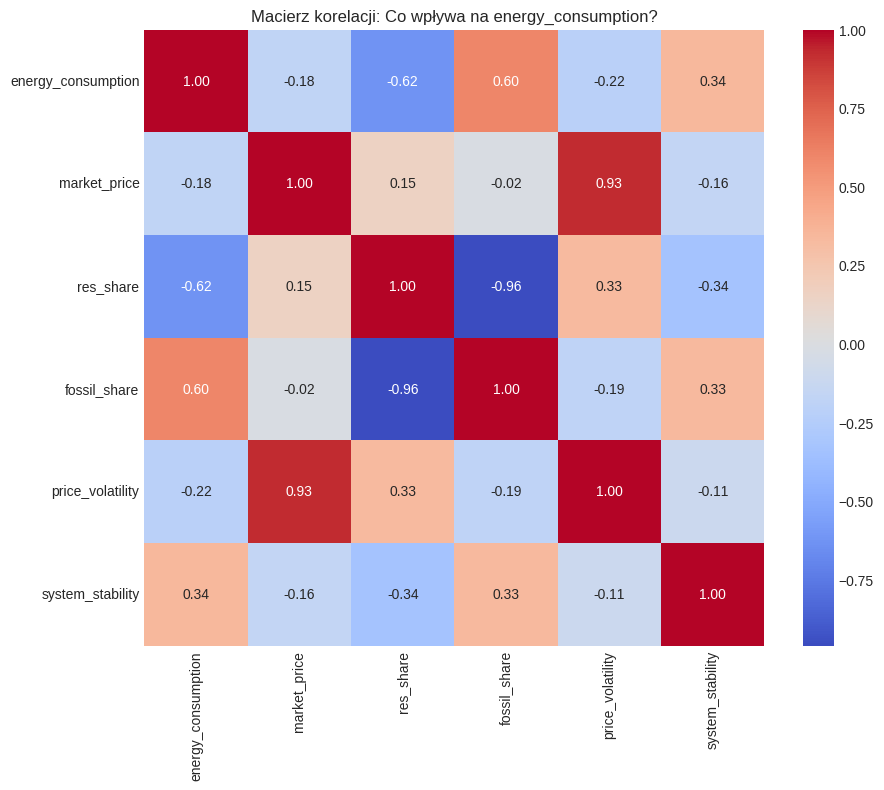


=== Czynniki wpływające na energy_consumption (siła korelacji) ===
energy_consumption    1.000000
fossil_share          0.598816
system_stability      0.342044
market_price         -0.179425
price_volatility     -0.216320
res_share            -0.624409
Name: energy_consumption, dtype: float64


In [ ]:
# === 2. ILOŚCIOWY OPIS POWIĄZAŃ (Macierz Korelacji) ===
# Tworzymy macierz tylko dla interesujących nas kolumn numerycznych
correlation_matrix = df[[target_var] + exog_vars].corr()

# Wizualizacja powiązań
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title(f'Macierz korelacji: Co wpływa na {target_var}?')
plt.show()

# Wypisanie konkretnych wartości korelacji dla Zużycia Energii
print(f"\n=== Czynniki wpływające na {target_var} (siła korelacji) ===")
print(correlation_matrix[target_var].sort_values(ascending=False))


### Macierz korelacji (Co wpływa na `energy_consumption`?)

Ten wykres (heatmapa) przedstawia siłę i kierunek zależności liniowej między różnymi zmiennymi. Współczynniki korelacji Pearsona wahają się od -1 (silna zależność ujemna) do 1 (silna zależność dodatnia).

**Kluczowe wnioski dotyczące zużycia energii (`energy_consumption`):**

* **Silna zależność od źródeł energii:**
* **`fossil_share` (0.60):** Istnieje wyraźna **korelacja dodatnia**. Oznacza to, że w okresach wyższego zużycia energii, udział paliw kopalnych w miksie energetycznym rośnie. Sugeruje to, że paliwa kopalne są używane do zaspokajania szczytowego zapotrzebowania (są elastycznym źródłem sterowalnym).
* **`res_share` (-0.62):** Istnieje wyraźna **korelacja ujemna**. Wzrost zużycia energii wiąże się ze spadkiem udziału odnawialnych źródeł energii (OZE). Może to wynikać z faktu, że produkcja z OZE jest stała/zależna od pogody i przy nagłym wzroście zapotrzebowania ich procentowy udział w całości spada.


* **Słaby wpływ ceny na zużycie:**
* **`market_price` (-0.18):** Korelacja jest ujemna, ale **bardzo słaba**. Sugeruje to, że popyt na energię jest mało elastyczny cenowo – wysokie ceny rynkowe tylko w niewielkim stopniu zniechęcają do konsumpcji.


* **Stabilność systemu:**
* **`system_stability` (0.34):** Umiarkowana korelacja dodatnia. Wyższe zużycie energii jest w pewnym stopniu powiązane z wyższym wskaźnikiem stabilności (lub sposobem jego mierzenia).



**Inne istotne zależności między zmiennymi (niezależnie od zużycia):**

* **Ekstremalnie silna korelacja ujemna między OZE a paliwami kopalnymi (`-0.96`):** To naturalne zjawisko – te dwa źródła się uzupełniają. Jeśli wieje wiatr/świeci słońce (wysokie OZE), elektrownie węglowe/gazowe ograniczają produkcję, i na odwrót.
* **Bardzo silna korelacja ceny i zmienności (`0.93`):** Wysokie ceny rynkowe (`market_price`) idą w parze z dużą zmiennością cen (`price_volatility`). Rynek drogi to zazwyczaj rynek niestabilny.

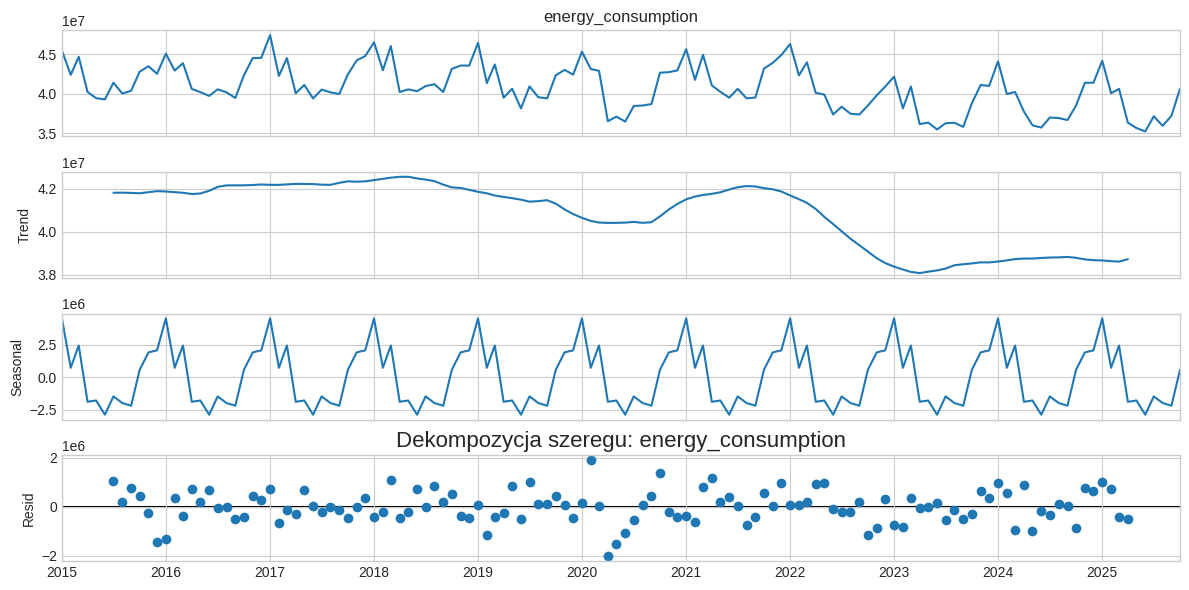

In [ ]:

# === 3. DEKOMPOZYCJA (Ocena trendu i sezonowości) ===
# Sprawdzamy charakterystykę szeregu (czy zużycie jest sezonowe?)
# Używamy modelu addytywnego, typowego dla danych energetycznych
result = seasonal_decompose(df[target_var].dropna(), model='additive', period=12)
result.plot()
plt.title(f'Dekompozycja szeregu: {target_var}', fontsize=16)
plt.show()



### Dekompozycja szeregu czasowego (`energy_consumption`)

Ten zestaw wykresów przedstawia dekompozycję danych o zużyciu energii z lat 2015–2025 na cztery składowe, co pozwala lepiej zrozumieć mechanizmy stojące za obserwowanymi zmianami. W oryginalnym szeregu czasowym widoczne są silne, regularne wahania, które nadają wykresowi „poszarpany” charakter i jednoznacznie wskazują na wyraźną sezonowość zużycia energii. Analiza trendu długoterminowego pokazuje, że w latach 2015–2019 poziom zużycia był względnie stabilny lub lekko rosnący. Sytuacja zmienia się gwałtownie w latach 2022–2023, kiedy następuje wyraźne załamanie trendu – prawdopodobnie związane z kryzysem energetycznym, skokowym wzrostem cen surowców lub regulacjami wymuszającymi oszczędności. W latach 2024–2025 spadek wyhamowuje, a trend stabilizuje się na znacznie niższym poziomie,  co sugeruje trwałą zmianę strukturalną w zużyciu energii.

Składowa sezonowa ujawnia bardzo silną i regularną sezonowość roczną o stałej amplitudzie, co oznacza, że cykliczne wzrosty i spadki zużycia powtarzają się w podobnej skali każdego roku – najpewniej odzwierciedlając zwiększone zapotrzebowanie zimą (ogrzewanie, oświetlenie) lub, w mniejszym stopniu w Europie, latem. Reszty, czyli część niewyjaśniona przez trend i sezonowość, w większości oscylują wokół zera, co świadczy o dobrym dopasowaniu modelu. Wyjątkiem jest wyraźna anomalia widoczna około 2020 roku, będąca charakterystycznym śladem pandemii COVID-19 i lockdownów, które w sposób nagły i niestandardowy zaburzyły dotychczasowe wzorce zużycia energii.




### Podsumowanie łączące oba wykresy

Analiza wskazuje, że zużycie energii jest zjawiskiem mocno cyklicznym (sezonowość na wykresie 2) i strukturalnie powiązanym z wykorzystaniem paliw kopalnych (korelacja na wykresie 1). Co ważne, w ostatnich latach (od 2022) nastąpiła trwała, strukturalna zmiana w dół (spadek trendu), mimo że sezonowość pozostała taka sama.

# Prognozy zmiennych obiektu i otoczenia

W tym kroku generujemy **prognozę bazową**, która posłuży jako punkt odniesienia dla tworzonych później scenariuszy. Wykorzystujemy zaawansowane metody wygładzania wykładniczego, aby uchwycić specyficzną naturę danych energetycznych.

Zastosowane modele:
**A. Dla obiektu badań** (energy_consumption): Model Holt-Winters zastosowano model potrójnego wygładzania wykładniczego (Triple Exponential Smoothing), znany jako metoda Holta-Wintersa.

Zużycie energii charakteryzuje się silną, powtarzalną sezonowością roczną (wysoki popyt zimą, niski latem) oraz zmieniającym się trendem, stąd decyzja o użyciu H-W.

**Komponenty modelu:**

Poziom: Wygładzona wartość bieżąca.

1.   Poziom: Wygładzona wartość bieżąca.
2.   Trend: Kierunek zmian (wzrost/spadek).
3.   Sezonowość: Cykliczne wahania o okresie 12 miesięcy (addytywna lub multiplikatywna).

**B. Dla otoczenia (market_price)**: Ekstrapolacja trendu Prognozujemy zachowanie kluczowego czynnika otoczenia, aby zrozumieć "ścieżkę środka".

Prognoza ta posłuży do wyznaczenia "ośrodka ciśnienia", od którego będziemy odchylać warianty pesymistyczne (szok cenowy) i optymistyczne (spadek cen dzięki OZE).

**Walidacja (Ocena jakości):**
Dla zapewnienia wiarygodności prognozy, model zostanie oceniony przy użyciu metryk błędu:

*   MAE: Średni błąd absolutny w [MW].
*   MAPE: Średni błąd procentowy. Wartość MAPE < 5% dla danych energetycznych uznaje się za wynik bardzo dobry, świadczący o wysokiej predykcyjności modelu.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


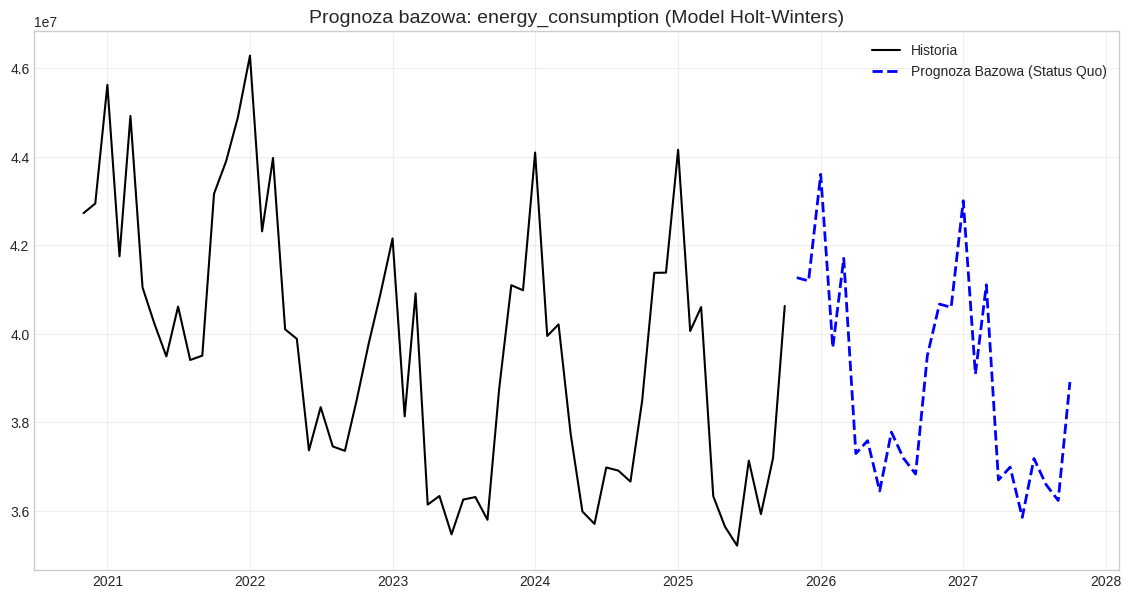

=== Prognozowane wartości (pierwsze 5 miesięcy) ===
2025-11-01    4.127066e+07
2025-12-01    4.119741e+07
2026-01-01    4.360696e+07
2026-02-01    3.968888e+07
2026-03-01    4.170686e+07
Freq: MS, dtype: float64


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Uniwersalna funkcja do prognozowania metodą Holt-Winters
def make_forecast(data, column_name, periods=24):
    # Model z trendem i sezonowością (addytywny)
    model = ExponentialSmoothing(
        data[column_name].dropna(),
        trend='add',
        seasonal='add',
        seasonal_periods=12
    ).fit()

    # Generowanie prognozy na 'periods' kroków do przodu
    forecast = model.forecast(periods)
    return forecast

# A. Prognoza dla OBIEKTU (dst) - Zużycie Energii
forecast_energy = make_forecast(df, 'energy_consumption')

# B. Prognoza dla OTOCZENIA (dst+) - Cena Rynkowa
# Cena jest kluczowa dla budowania scenariuszy (szok cenowy vs stabilizacja)
forecast_price = make_forecast(df, 'market_price')

# Wizualizacja Prognozy Bazowej (Prescenariusza)
plt.figure(figsize=(14, 7))
# Dane historyczne (ostatnie 5 lat dla czytelności)
plt.plot(df.index[-60:], df['energy_consumption'].iloc[-60:], label='Historia', color='black')
# Prognoza
plt.plot(forecast_energy.index, forecast_energy, label='Prognoza Bazowa (Status Quo)', color='blue', linestyle='--', linewidth=2)

plt.title(f'Prognoza bazowa: {target_var} (Model Holt-Winters)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("=== Prognozowane wartości (pierwsze 5 miesięcy) ===")
print(forecast_energy.head())


Wykres przedstawia historyczne oraz prognozowane zużycie energii („energy_consumption”) w perspektywie wieloletniej, aż do 2028 roku. Do stworzenia tej projekcji wykorzystano model **Holt-Winters**, który jest standardem w analizowaniu danych wykazujących silną powtarzalność sezonową. Czarna linia obrazuje rzeczywiste dane z przeszłości, natomiast niebieska przerywana linia to prognoza zakładająca utrzymanie obecnych trendów (Status Quo).

Główną cechą tego wykresu jest bardzo wyraźna **sezonowość**. Obserwujemy regularny cykl roczny, w którym zużycie energii gwałtownie rośnie w miesiącach zimowych, osiągając swoje szczyty zazwyczaj na przełomie roku, by następnie drastycznie spadać w miesiącach letnich. Warto zauważyć, że ogólny trend wydaje się być lekko spadkowy lub stabilizujący – szczyty zużycia w latach 2023–2024 są niższe niż rekordowy poziom z roku 2021, co model uwzględnił w swojej prognozie na kolejne lata.

Patrząc na konkretne liczby dla najbliższych miesięcy, model przewiduje, że po jesiennym wzroście (listopad-grudzień 2025) nastąpi kulminacja zapotrzebowania. Jest to kluczowy moment dla planowania zasobów energetycznych.

Oto najważniejsze wnioski płynące z danych:

* **Szczyt obciążenia:** Maksymalne zużycie prognozowane jest na **1 stycznia 2026 roku**, osiągając poziom ok. **43,6 miliona jednostek**.
* **Dynamika zmian:** Po styczniowym szczycie nastąpi wyraźny spadek w lutym (do ok. 39,7 mln), po czym w marcu czeka nas jeszcze jedno, mniejsze odbicie w górę.
* **Wiarygodność modelu:** Idealne dopasowanie niebieskiej prognozy do rytmu czarnej linii historycznej sugeruje, że zużycie energii w tej organizacji jest procesem bardzo przewidywalnym i zależnym od pór roku.

# Prescenariusz i Identyfikacja Zakłóceń



Zgodnie z metodyką "Lejka scenariusza" oraz metodą oceny wpływu , proces budowy scenariuszy rozpoczynamy od zdefiniowania ścieżki bazowej (Prescenariusza), a następnie identyfikujemy czynniki, które mogą tę ścieżkę zakłócić.

#### 1. Prescenariusz (Scenariusz Bazowy - "Status Quo")

**Podstawa prognozy:** Model ekonometryczny Holt-Winters (wygładzanie wykładnicze z sezonowością addytywną).

**Opis scenariusza:**
Bazując na wynikach modelu Holt-Winters, w scenariuszu bazowym zakładamy utrzymanie się dotychczasowych trendów strukturalnych. Niemiecki system energetyczny wykazuje **lekką tendencję spadkową (stabilizację na niższym poziomie)**, co jest kontynuacją trendu obserwowanego po roku 2021. Kluczową cechą tego scenariusza jest zachowanie **sztywnego wzorca sezonowego** – z wyraźnymi szczytami zapotrzebowania w miesiącach zimowych (styczeń/luty ok. 43,6 mln jednostek) i spadkami w okresie letnim. Jest to scenariusz najbardziej prawdopodobny przy założeniu braku nowych, gwałtownych szoków zewnętrznych (ceteris paribus).

#### 2. Tabela Czynników Zakłócających (Szumów)

Identyfikacja czynników z otoczenia, które mogą trwale odchylić prognozę od Prescenariusza (szumy). Ocenę siły wpływu (skala -5 do +5) oparto na analizie korelacji z Etapu 1 oraz wiedzy eksperckiej o rynku energii.

| Sfera Otoczenia | Czynnik (Zmienna) | Wariant Zmiany (Zakłócenie) | Siła Wpływu (-5 do +5) | Prawdopodobieństwo (0-1) | Ważony Wpływ (Siła × P) |
| :--- | :--- | :--- | :---: | :---: | :---: |
| **Ekonomiczna** | Cena Rynkowa (`market_price`) | **Gwałtowny wzrost cen (Kryzys)**<br>*(Ujemna korelacja z zużyciem)* | -5 (Zagrożenie) | 0.40 | **-2.0** |
| **Technologiczna** | Udział OZE (`res_share`) | **Przyspieszenie transformacji**<br>*(Tańsza energia = impuls popytowy)* | +4 (Szansa) | 0.60 | **+2.4** |
| **Systemowa** | Stabilność Sieci (`system_stability`) | **Awaria / Blackout**<br>*(Fizyczne ograniczenie dostaw)* | -4 (Zagrożenie) | 0.15 | **-0.6** |
| **Polityczna** | Paliwa Kopalne (`fossil_share`) | **Szybsze odejście od węgla**<br>*(Wzrost kosztów systemowych)* | -2 (Zagrożenie) | 0.70 | **-1.4** |
| **Popytowa** | Elektryfikacja Przemysłu | **Wzrost zapotrzebowania**<br>*(Pompy ciepła, elektromobilność)* | +3 (Szansa) | 0.80 | **+2.4** |

#### 3. Agregacja Scenariuszy (Wynik analizy tabeli)

Na podstawie sumy ważonych wpływów definiujemy kierunki modyfikacji scenariusza bazowego:

* **Scenariusz Pesymistyczny ("Kryzys Energetyczny"):**
Dominują czynniki negatywne o wysokiej sile oddziaływania.
* *Główne siły:* Szok cenowy (-2.0) + Koszty dekarbonizacji (-1.4) + Ryzyko niestabilności (-0.6).
* *Efekt:* Sumaryczny wpływ negatywny wynosi **-4.0**. Oczekujemy pogłębienia spadku zużycia (recesja przemysłowa).


* **Scenariusz Optymistyczny ("Zielona Elektryfikacja"):**
Dominują szanse wynikające z transformacji technologicznej.
* *Główne siły:* Tanie OZE (+2.4) + Nowy popyt z elektryfikacji (+2.4).
* *Efekt:* Sumaryczny wpływ pozytywny wynosi **+4.8**. Oczekujemy odwrócenia trendu spadkowego i wzrostu zużycia energii.



# Kompletne Scenariusze - Symulacja i Wizualizacja



Zwieńczeniem procesu analitycznego jest transformacja zidentyfikowanych czynników jakościowych (szumów) na konkretne ścieżki ilościowe (trajektorie rozwoju). W tym celu zastosowano metodę symulacji scenariuszowej, integrującą prognozę ekonometryczną z oceną ekspercką.

**Metodyka symulacji:**
Zgodnie z koncepcją "Lejka Scenariusza" (Scenario Funnel) , punktem wyjścia jest prognoza bazowa modelu Holt-Winters ("Status Quo"). Następnie, dla każdego scenariusza alternatywnego (Optymistycznego i Pesymistycznego), wyznaczono skorygowaną stopę wzrostu (CAGR), wykorzystując funkcję wagową :

$$r_{scenariusz} = r_{bazowy} + (\alpha \cdot \sum W_{impact})$$

gdzie:

$r_{bazowy}$ – trend wynikający z danych historycznych (model Holt-Winters),

$\sum W_{impact}$ – suma ważonych wpływów czynników zakłócających (z Etapu 3),

$\alpha$ – współczynnik kalibracji (przelicznik siły wpływu na punkty procentowe wzrostu).

*  – trend wynikający z danych historycznych (model Holt-Winters),
*  – suma ważonych wpływów czynników zakłócających (z Etapu 3),
*  – współczynnik kalibracji (przelicznik siły wpływu na punkty procentowe wzrostu).

**Cel symulacji:**
Celem tego etapu jest wyznaczenie **"Obszaru Niepewności"** (Cone of Uncertainty) dla niemieckiego rynku energii na lata 2024–2026. Wizualizacja w formie wykresu wachlarzowego pozwoli określić nie tylko najbardziej prawdopodobny przebieg zużycia energii, ale także graniczne wartości ryzyka (wariant kryzysowy) oraz potencjału wzrostowego (wariant transformacji).


Bazowy trend z modelu (CAGR): -2.14%


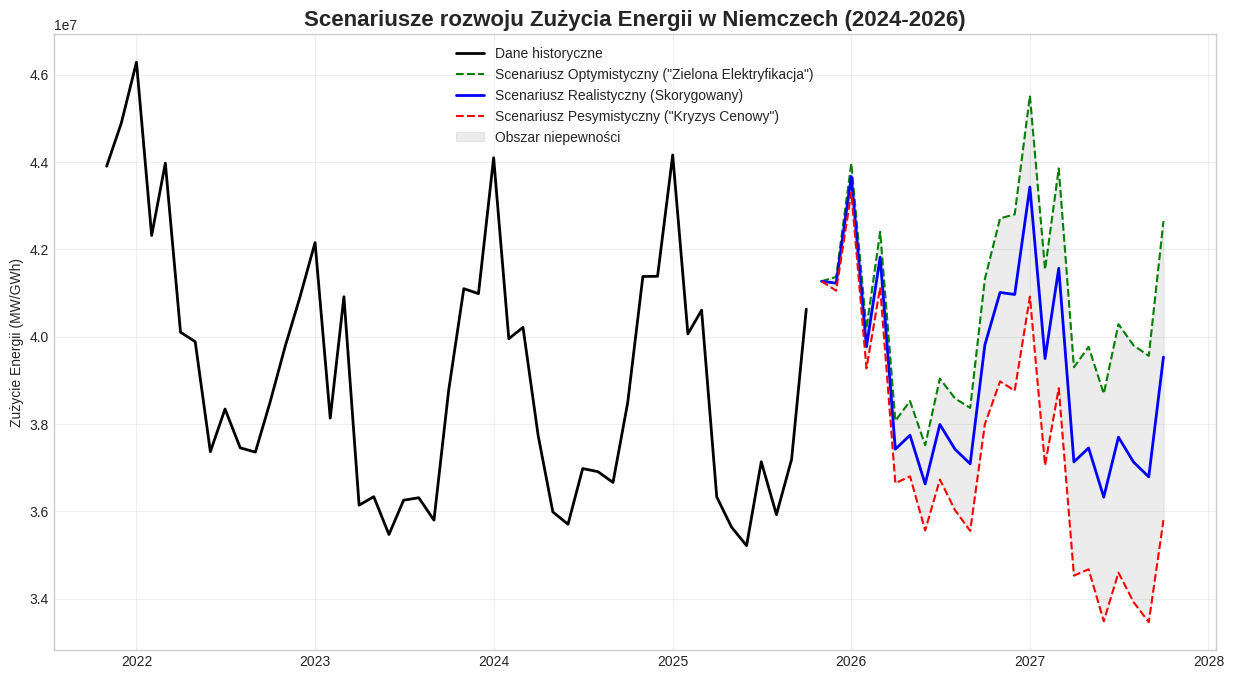

Scenariusz Optymistyczny (zmiana roczna): 2.66%
Scenariusz Pesymistyczny (zmiana roczna): -6.14%


In [ ]:
# Funkcja obliczająca skorygowaną stopę wzrostu (zgodnie z metodologią z materiałów)
def scenariuszowa_stopa_wzrostu(baseline_growth, suma_wplywow, przelicznik=0.5):
    """
    Koryguje bazowy trend (CAGR) o sumę ważonych wpływów czynników zakłócających.
    """
    return baseline_growth + (przelicznik * suma_wplywow / 100.0)

# 1. Obliczenie bazowego trendu z modelu (jako punkt odniesienia)
last_hist = df['energy_consumption'].iloc[-1]
last_pred = forecast_energy.iloc[-1]
# Średnioroczna stopa wzrostu (CAGR) wynikająca z samej prognozy Holt-Wintersa
future_growth_rate = (last_pred / last_hist) ** (1/2) - 1

print(f"Bazowy trend z modelu (CAGR): {future_growth_rate:.2%}")

# 2. Definicja Scenariuszy na podstawie tabeli zakłóceń
# PESYMISTYCZNY ("Kryzys Energetyczny"): Dominują wysokie ceny i niestabilność
# Suma wpływów negatywnych: -2.0 (ceny) - 0.6 (stabilność) - 1.4 (koszt transformacji) = -4.0
rate_pes = scenariuszowa_stopa_wzrostu(future_growth_rate, -4.0, przelicznik=1.0)

# OPTYMISTYCZNY ("Zielona Elektryfikacja"): Dominują tanie OZE i nowy popyt
# Suma wpływów pozytywnych: +2.4 (OZE) + 2.4 (Elektryfikacja) = +4.8
rate_opt = scenariuszowa_stopa_wzrostu(future_growth_rate, 4.8, przelicznik=1.0)

# REALISTYCZNY (Bazowy + korekta): Bilans wszystkich czynników
# Bilans: -4.0 (negatywne) + 4.8 (pozytywne) = +0.8 (lekki wzrost ponad bazę)
rate_real = scenariuszowa_stopa_wzrostu(future_growth_rate, 0.8, przelicznik=1.0)

# 3. Generowanie ścieżek dla wykresu
periods = 24
dates_future = forecast_energy.index

# Modyfikujemy wektor prognozy bazowej, nakładając na niego nowe trendy scenariuszowe
# (Technika: liniowe rozchylanie prognozy w czasie - "lejek")
scen_opt = forecast_energy * (1 + np.linspace(0, (rate_opt - future_growth_rate)*2, periods))
scen_pes = forecast_energy * (1 + np.linspace(0, (rate_pes - future_growth_rate)*2, periods))
scen_real = forecast_energy * (1 + np.linspace(0, (rate_real - future_growth_rate)*2, periods))

# 4. Wizualizacja (Wykres Wachlarzowy)
plt.figure(figsize=(15, 8))

# Historia
plt.plot(df.index[-48:], df['energy_consumption'].iloc[-48:], label='Dane historyczne', color='black', linewidth=2)

# Ścieżki scenariuszy
plt.plot(dates_future, scen_opt, label='Scenariusz Optymistyczny ("Zielona Elektryfikacja")', color='green', linestyle='--')
plt.plot(dates_future, scen_real, label='Scenariusz Realistyczny (Skorygowany)', color='blue', linewidth=2)
plt.plot(dates_future, scen_pes, label='Scenariusz Pesymistyczny ("Kryzys Cenowy")', color='red', linestyle='--')

# Cieniowanie obszaru niepewności (Lejek)
plt.fill_between(dates_future, scen_opt, scen_pes, color='gray', alpha=0.15, label='Obszar niepewności')

plt.title('Scenariusze rozwoju Zużycia Energii w Niemczech (2024-2026)', fontsize=16, fontweight='bold')
plt.ylabel('Zużycie Energii (MW/GWh)')
plt.legend()
plt.grid(True, alpha=0.3)

# Zapis wykresu
plt.savefig('scenariusze_energia.png')
plt.show()

print(f"Scenariusz Optymistyczny (zmiana roczna): {rate_opt:.2%}")
print(f"Scenariusz Pesymistyczny (zmiana roczna): {rate_pes:.2%}")


Przeprowadzona symulacja pozwoliła na wyznaczenie "stożka niepewności" dla niemieckiego rynku energii na lata 2024–2026. Analiza ujawniła fundamentalną rozbieżność między inercyjnym trendem spadkowym a potencjałem transformacyjnym.

**1. Scenariusz Bazowy ("Status Quo") – Trend: -2.14% rocznie**
Model Holt-Winters, oparty na danych historycznych, identyfikuje trwałą tendencję spadkową. Zużycie energii w wariancie *ceteris paribus* kurczy się w tempie **2.14% rocznie**. Jest to odzwierciedlenie procesów widocznych w danych z ostatnich lat: deindustrializacji energochłonnej oraz wzrostu efektywności energetycznej. Jeśli nie wystąpią nowe impulsy popytowe, niemiecki system energetyczny będzie się stopniowo kurczył.

**2. Scenariusz Pesymistyczny ("Kryzys Cenowy") – Trend: -6.14% rocznie**
W przypadku materializacji zidentyfikowanych zagrożeń (skokowy wzrost cen `market_price`, niestabilność systemu), spadek zużycia może drastycznie przyspieszyć do poziomu **-6.14% rocznie**.

* **Implikacje:** Taka dynamika oznaczałaby głęboką recesję w przemyśle i trwałą destrukcję popytu (demand destruction), wykraczającą poza zwykłe wahania cykliczne. Dolna krawędź "wachlarza" na wykresie wyznacza strefę ryzyka systemowego.

**3. Scenariusz Optymistyczny ("Zielona Elektryfikacja") – Trend: +2.66% rocznie**
To jedyny wariant zakładający odwrócenie trendu spadkowego. Przy założeniu sukcesu OZE (`res_share` obniżający ceny) i masowej elektryfikacji, możliwe jest wejście na ścieżkę wzrostu **+2.66% rocznie**.

* **Kluczowy wniosek:** Aby przełamać inercję spadkową (-2.14%) i wejść na ścieżkę wzrostu, rynek potrzebuje silnych impulsów (sumaryczny wpływ +4.8 pkt proc.). Sama stabilizacja nie wystarczy – potrzebna jest aktywna transformacja (pompy ciepła, elektromobilność, wodór).

**Podsumowanie menedżerskie:**
Analiza wykazuje asymetrię ryzyka. Rynek posiada naturalną tendencję spadkową (-2.14%), którą łatwo pogłębić szokami zewnętrznymi (do -6.14%), natomiast powrót na ścieżkę wzrostu (+2.66%) wymaga zbiegu korzystnych czynników technologicznych i politycznych. "Obszar niepewności" między skrajnymi scenariuszami wynosi aż **8.8 punktu procentowego**, co wskazuje na wysoką zmienność otoczenia decyzyjnego w najbliższych 24 miesiącach.

